# Arboles de Regresion

En este codigo vamos a emplear un modelo de arbol de regresion para predecir la propina de un viaje.

### SETUP
Como siempre, instalamos e importamos las dependencias numpy, pandas, matplotlib y scikit y descargamos el dataset. 

In [12]:
#Descargamos librerias
!pip install -q numpy
!pip install -q pandas
!pip install -q matplotlib
!pip install -q scikit-learn

#Importamos librerias
from __future__ import print_function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

import warnings
warnings.filterwarnings('ignore')

#Descargamos dataset
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv'
raw_data = pd.read_csv(url)


## Estudio del dataset

Analicemos las variables que tenemos dentro de nuestro dataset, a fin de determinar cuales son utilizables y cuales requieren alguna transformación.

In [13]:
# Imprimimos los tipos de cada variable en nuestro dataset junto con un sample y un recuento de valores nulos
print("------------------------------TYPES-----------------------------------------")
print(raw_data.dtypes)
print("-------------------------------------------------------SAMPLES-----------------------------------------------------------------------")
print(raw_data.sample(3))
print("-------------------------------------------------------COUNTS------------------------------------------------------------------------")
print(raw_data.isnull().sum())


------------------------------TYPES-----------------------------------------
VendorID                   int64
passenger_count            int64
trip_distance            float64
RatecodeID                 int64
store_and_fwd_flag         int64
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
mta_tax                  float64
tolls_amount             float64
improvement_surcharge      int64
tip_amount               float64
dtype: object
-------------------------------------------------------SAMPLES-----------------------------------------------------------------------
       VendorID  passenger_count  trip_distance  RatecodeID  \
8952          2                2          18.94           2   
25333         2                4          28.47           2   
9285          2                2          20.54           2   

       store_and_fwd_flag  PULocationID  DOLocationID  payment_type  \
8952                  

Viendo que todas las variables son numericas y no tenemos valores nulos concluimos que no es necesario hacer un procesamiento de la información momentaneamente, podemos entonces proceder a realizar un estudio de correlaciones

### Correlaciones

Teniendo en cuenta que nuestro modelo pretende predecir la propina de un nuevo viaje, tomemos como variable objetivo `tip_amount` y armemos un grafico de correlaciones

<Axes: title={'center': 'Correlaciones con propina'}>

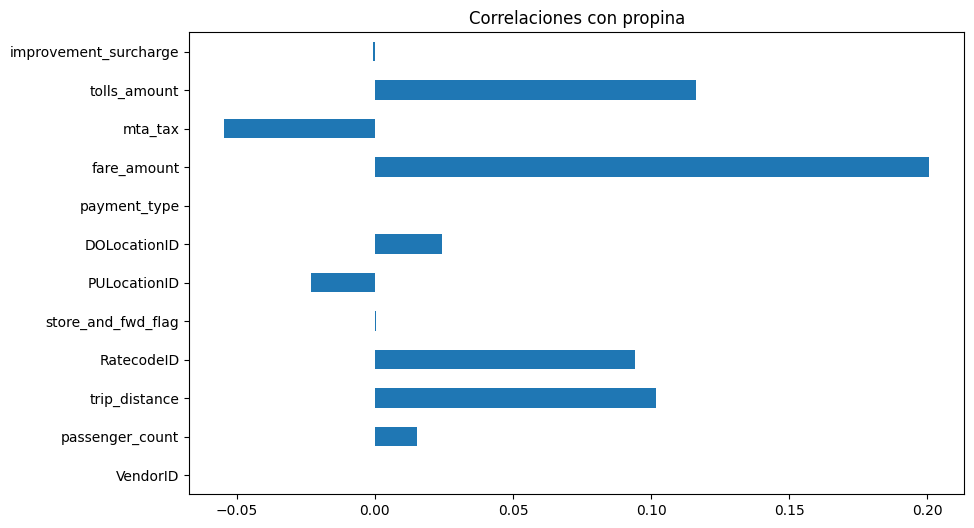

In [14]:
correlation_values = raw_data.corr()['tip_amount'].drop('tip_amount')
correlation_values.plot(kind='barh', figsize=(10, 6), title="Correlaciones con propina")

Gracias a este grafico podemos decidir cuales variables no seran utilizadas en nuestro modelo, en particular `VendorID`,`store_and_fwd_flag`, `imporvement_surcharge` y `payment_type`. Podemos entonces pasar al preprocesamiento de nuestros datos.

## Preprocesamiento del Dataset

Ahora tomemos como variable objetivo `tip_amount`, el resto serán nuestros features y separemos nuestro dataset en grupo de entrenamiento y validacion.

In [15]:
# Definimos variable objetivo
y = raw_data[['tip_amount']].values.astype('float32')

# Sacamos variable objetivo de nuestra lista de variables
proc_data = raw_data.drop(['tip_amount'], axis=1)

# Definimos como features a la lista de variables 
X = proc_data.values

# Normalizamos los valores de nuestros features para arreglar magnitudes
X = normalize(X, axis=1, norm='l1', copy=False)

# Separamos dataset en valores de entrenamiento y validacion
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Creacion y Estudio del Modelo

Teniendo definidos nuestros grupos de datos, variable objetivo y features podemos armar el modelo de Arbol de Regresión, para esto es importante definir el [criterion](./README.md) y [max_depth](./README.md). <br>
Teniendo nuestro modelo armado lo entrenamos y analizamos sus métricas de desempeño.

In [16]:
# Armamos modelo
dt_reg = DecisionTreeRegressor(criterion = 'squared_error',
                               max_depth=8, 
                               random_state=35)

# Entrenamos modelo
dt_reg.fit(X_train, y_train)

# Obtenemos predicciones del modelo 
y_pred = dt_reg.predict(X_test)

# Analizamos desempeño
mse_score = mean_squared_error(y_test, y_pred)
print('MSE score : {0:.3f}'.format(mse_score))

r2_score = dt_reg.score(X_test,y_test)
print('R^2 score : {0:.3f}'.format(r2_score))

MSE score : 24.555
R^2 score : 0.028
